In [1]:
import numpy as np
import matplotlib.pyplot as plt
from control import *
import sys
sys.path.append('../..')
from simulation.model.motor_params import *

In [2]:
# DC Motor State Space Model
# States:  x = [i, omega, theta]
# Input:   u = U (voltage)
# Output:  y = theta

A = np.array([[-R/L,   -Ke/L,  0],
              [ Kt/J,  -B/J,   0],
              [ 0,      1,     0]])

B = np.array([[1/L],
              [0  ],
              [0  ]])

C = np.array([[0, 0, 1]])
D = np.array([[0]])

motor_ss = ss(A, B, C, D)
print(motor_ss)

<StateSpace>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (3): ['x[0]', 'x[1]', 'x[2]']

A = [[-4.e+03 -2.e+02  0.e+00]
     [ 1.e+01 -1.e-01  0.e+00]
     [ 0.e+00  1.e+00  0.e+00]]

B = [[2000.]
     [   0.]
     [   0.]]

C = [[0. 0. 1.]]

D = [[0.]]


In [3]:
# LQR design
# Q - state cost matrix (how much we penalize state error)
# R - input cost matrix (how much we penalize control effort)

Q = np.diag([1, 1, 100])
R = np.array([[1]])

K, S, E = lqr(A, B, Q, R) 
print(f'LQR gain matrix K: {K}')
print(f'Closed loop poles: {E}')

LQR gain matrix K: [[ 0.2410312   2.22208588 10.        ]]
Closed loop poles: [-4471.686451  +0.j            -5.23797884+4.15805636j
    -5.23797884-4.15805636j]


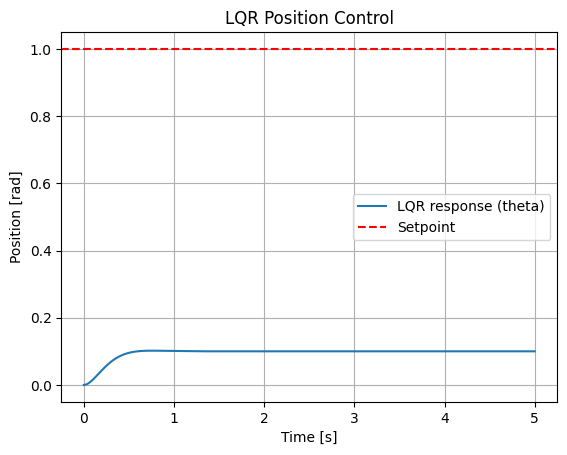

In [10]:
# Closed loop system with LQR
# u = -K*x

A_cl = A - B @ K
sys_lqr = ss(A_cl, B, C, D)

t = np.linspace(0, 5, 1000)
t, y = step_response(sys_lqr, T=t)

plt.plot(t, y, label='LQR response (theta)')
plt.axhline(y=1.0, color='r', linestyle='--', label='Setpoint')
plt.xlabel('Time [s]')
plt.ylabel('Position [rad]')
plt.title('LQR Position Control')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# LQI - LQR with integral action
# Extended state: x_aug = [i, omega, theta, e_int]
# e_int_dot = theta_ref - theta

A_aug = np.zeros((4, 4))
A_aug[:3, :3] = A
A_aug[3, 2] = -1  # integrate theta to eliminate error

B_aug = np.zeros((4, 1))
B_aug[:3, :] = B

C_aug = np.array([[0, 0, 1, 0]])  # output is still theta
D_aug = np.array([[0]])

print('Augmented A:')
print(A_aug)
print('\nAugmented B:')
print(B_aug)

Augmented A:
[[-4.e+03 -2.e+02  0.e+00  0.e+00]
 [ 1.e+01 -1.e-01  0.e+00  0.e+00]
 [ 0.e+00  1.e+00  0.e+00  0.e+00]
 [ 0.e+00  0.e+00 -1.e+00  0.e+00]]

Augmented B:
[[2000.]
 [   0.]
 [   0.]
 [   0.]]


In [13]:
# LQI design
# Q_aug - now penalizing 4 states including integral
Q_aug = np.diag([1, 1, 100, 400])  # penalize integral error heavily
R_aug = np.array([[0.1]])

K_aug, S_aug, E_aug = lqr(A_aug, B_aug, Q_aug, R_aug)
print(f'LQI gain matrix K: {K_aug}')
print(f'Closed loop poles: {E_aug}')

LQI gain matrix K: [[  1.75012483   6.34362057  42.65916395 -63.2455532 ]]
Closed loop poles: [-7.48304273e+03+0.j         -7.63322719e+00+4.95742781j
 -7.63322719e+00-4.95742781j -2.04046849e+00+0.j        ]


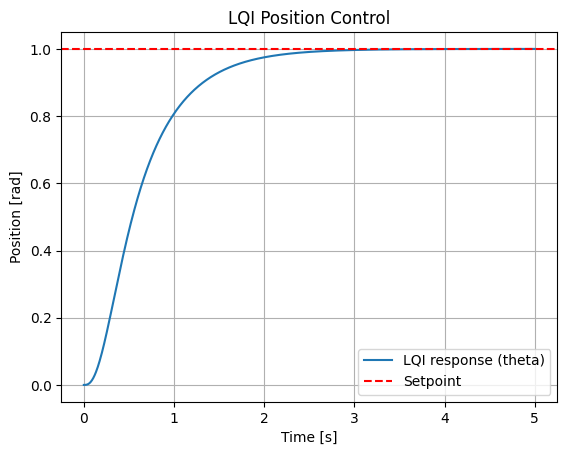

In [14]:
# Closed loop simulation with LQI
A_cl_aug = A_aug - B_aug @ K_aug

# We need to simulate with reference input
# u = -K*x + K_i * e_int is already included in augmented system
# Add reference input to integrator
B_ref = np.array([[0], [0], [0], [1]])  # reference enters through integrator

sys_lqi = ss(A_cl_aug, B_ref, C_aug, D_aug)

t = np.linspace(0, 5, 1000)
t, y = step_response(sys_lqi, T=t)

plt.plot(t, y, label='LQI response (theta)')
plt.axhline(y=1.0, color='r', linestyle='--', label='Setpoint')
plt.xlabel('Time [s]')
plt.ylabel('Position [rad]')
plt.title('LQI Position Control')
plt.legend()
plt.grid(True)
plt.show()

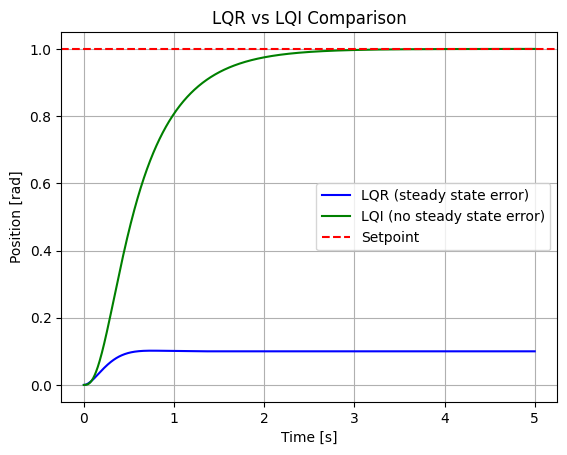

In [15]:
# Comparison: LQR vs LQI
t = np.linspace(0, 5, 1000)
t, y_lqr = step_response(sys_lqr, T=t)
t, y_lqi = step_response(sys_lqi, T=t)

plt.plot(t, y_lqr, 'b', label='LQR (steady state error)')
plt.plot(t, y_lqi, 'g', label='LQI (no steady state error)')
plt.axhline(y=1.0, color='r', linestyle='--', label='Setpoint')
plt.xlabel('Time [s]')
plt.ylabel('Position [rad]')
plt.title('LQR vs LQI Comparison')
plt.legend()
plt.grid(True)
plt.show()